<a href="https://colab.research.google.com/github/zagladney/hw6-stat175/blob/main/GCN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graph Neural Networks



# Preliminaries: PyTorch


We'll start by importing everything we need:

In [ ]:
#import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import sklearn.metrics as metrics


# Setup

Let's first install PyTorch Geometric (which we'll use for creating graph neural networks) and TensorboardX (which we'll use to visualize training progress):

Warning: The next step can be slow if you are using the default colab but it will finish.


In [ ]:
!pip install --verbose --no-cache-dir torch-scatter
!pip install --verbose --no-cache-dir torch-sparse
!pip install --verbose --no-cache-dir torch-cluster
!pip install torch-geometric
!pip install tensorboardX
!wget https://bin.equinox.io/c/4VmDzA7iaHb/ngrok-stable-linux-amd64.zip
!unzip ngrok-stable-linux-amd64.zip

Using pip 24.1.2 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 10.2 MB/s eta 0:00:00
  Running command python setup.py egg_info
  running egg_info
  creating /tmp/pip-pip-egg-info-58pa62tg/torch_scatter.egg-info
  writing /tmp/pip-pip-egg-info-58pa62tg/torch_scatter.egg-info/PKG-INFO
  writing dependency_links to /tmp/pip-pip-egg-info-58pa62tg/torch_scatter.egg-info/dependency_links.txt
  writing requirements to /tmp/pip-pip-egg-info-58pa62tg/torch_scatter.egg-info/requires.txt
  writing top-level names to /tmp/pip-pip-egg-info-58pa62tg/torch_scatter.egg-info/top_level.txt
  writing manifest file '/tmp/pip-pip-egg-info-58pa62tg/torch_scatter.egg-info/SOURCES.txt'
  reading manifest file '/tmp/pip-pip-egg-info-58pa62tg/torch_scatter.egg-info/SOURCES.txt'
  reading manifest template 'MANIFEST.in'
  adding license file 'LICENSE'
  writing manifest file '/tmp/pip-pip-egg-info-58pa62tg/torch_scatter.egg-info/SOURCES

Import everything we need:

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch_geometric.nn as pyg_nn
import torch_geometric.utils as pyg_utils

import time
from datetime import datetime

import networkx as nx
import numpy as np
import torch
import torch.optim as optim

from torch_geometric.datasets import TUDataset
from torch_geometric.datasets import Planetoid
from torch_geometric.data import DataLoader

import torch_geometric.transforms as T

from tensorboardX import SummaryWriter
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


# Defining the model

The `GNNStack` is our general framework for a GNN which can handle different types of convolutional layers, when we are interested in node classification (so we specialized to this setting but you can modify it). We choose to use a graph convolutional network for our task. Note that PyTorch Geometric provides out-of-the-box modules for these layers, which we use here. The model consists of 3 layers of convolution with normalization. Followed by two layers of fully-connected
NN. Since our goal here is classification, we use a negative log-likelihood loss function.

In [ ]:
class GNNStack(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, task='node'):
        super(GNNStack, self).__init__()
        self.task = task
        self.convs = nn.ModuleList()
        self.convs.append(self.build_conv_model(input_dim, hidden_dim))
        self.lns = nn.ModuleList()
        self.lns.append(nn.LayerNorm(hidden_dim))
        self.lns.append(nn.LayerNorm(hidden_dim))
        for l in range(2):
            self.convs.append(self.build_conv_model(hidden_dim, hidden_dim))

        # post-message-passing
        self.post_mp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.Dropout(0.25),
            nn.Linear(hidden_dim, output_dim))
        if not (self.task == 'node' ):
            raise RuntimeError('Unknown task.')

        self.dropout = 0.25
        self.num_layers = 3

    def build_conv_model(self, input_dim, hidden_dim):
        # refer to pytorch geometric nn module for different implementation of GNNs.
        if self.task == 'node':
            return pyg_nn.GCNConv(input_dim, hidden_dim)
        else:
            return pyg_nn.GINConv(nn.Sequential(nn.Linear(input_dim, hidden_dim),
                                  nn.ReLU(), nn.Linear(hidden_dim, hidden_dim)))

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        if data.num_node_features == 0:
          x = torch.ones(data.num_nodes, 1)

        for i in range(self.num_layers):
            x = self.convs[i](x, edge_index)
            emb = x
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            if not i == self.num_layers - 1:
                x = self.lns[i](x)


        x = self.post_mp(x)

        return emb, F.log_softmax(x, dim=1)

    def loss(self, pred, label):
        return F.nll_loss(pred, label)

Here pyg_nn.GCNConv and pyg_nn.GINConv are instances of MessagePassing. They define a single layer of graph convolution, which can be decomposed into:
* Message computation
* Aggregation
* Update
* Pooling

Here we give an example of how to subclass the pytorch geometric MessagePassing class to derive a new model (rather than using existing GCNConv and GINConv).

We make use of `MessagePassing`'s key building blocks:
- `aggr='add'`: The aggregation method to use ("add", "mean" or "max").
- `propagate()`: The initial call to start propagating messages. Takes in the edge indices and any other data to pass along (e.g. to update node embeddings).
- `message()`: Constructs messages to node i. Takes any argument which was initially passed to propagate().
- `update()`: Updates node embeddings. Takes in the output of aggregation as first argument and any argument which was initially passed to propagate().


In [ ]:
class CustomConv(pyg_nn.MessagePassing):
    def __init__(self, in_channels, out_channels):
        super(CustomConv, self).__init__(aggr='add')  # "Add" aggregation.
        self.lin = nn.Linear(in_channels, out_channels)
        self.lin_self = nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index):
        # x has shape [N, in_channels]
        # edge_index has shape [2, E]

        # Add self-loops to the adjacency matrix.
        edge_index, _ = pyg_utils.remove_self_loops(edge_index)

        # Transform node feature matrix.
        self_x = self.lin_self(x)
        #x = self.lin(x)

        return self_x + self.propagate(edge_index, size=(x.size(0), x.size(0)), x=self.lin(x))

    def message(self, x_i, x_j, edge_index, size):
        # Compute messages
        # x_j has shape [E, out_channels]

        row, col = edge_index
        deg = pyg_utils.degree(row, size[0], dtype=x_j.dtype)
        deg_inv_sqrt = deg.pow(-0.5)
        norm = deg_inv_sqrt[row] * deg_inv_sqrt[col]

        return x_j

    def update(self, aggr_out):
        # aggr_out has shape [N, out_channels]
        return aggr_out

# Training setup

We train the model in a standard way here, running it forwards to compute its predicted label distribution and backpropagating the error. Note the task setup in our graph setting: for node classification, we define a subset of nodes to be training nodes and the rest of the nodes to be test nodes, and mask out the test nodes during training via `batch.train_mask`.

In [ ]:
def train(dataset,  writer):

    test_loader = loader = DataLoader(dataset, batch_size=64, shuffle=True)

    # build model
    model = GNNStack(max(dataset.num_node_features, 1), 32, dataset.num_classes, task="node")
    opt = optim.Adam(model.parameters(), lr=0.01)

    # train
    for epoch in range(200):
        total_loss = 0
        model.train()
        for batch in loader:
            #print(batch.train_mask, '----')
            opt.zero_grad()
            embedding, pred = model(batch)
            label = batch.y

            pred = pred[batch.train_mask]
            label = label[batch.train_mask]
            loss = model.loss(pred, label)
            loss.backward()
            opt.step()
            total_loss += loss.item() * batch.num_graphs
        total_loss /= len(loader.dataset)
        writer.add_scalar("loss", total_loss, epoch)

        if epoch % 10 == 0:
            test_acc = test(test_loader, model)
            print("Epoch {}. Loss: {:.4f}. Test accuracy: {:.4f}".format(
                epoch, total_loss, test_acc))
            writer.add_scalar("test accuracy", test_acc, epoch)
            macro_f1 = testF1(test_loader, model)
            print("Test Macro F1 Score: {:.4f}".format(macro_f1))
    return model


Test time, for the CiteSeer/Cora node classification task, there is only 1 graph. So we use masking to determine validation and test set.


In [ ]:
def test(loader, model, is_validation=False):
    model.eval()

    correct = 0
    for data in loader:
        with torch.no_grad():
            emb, pred = model(data)
            pred = pred.argmax(dim=1)
            label = data.y


        mask = data.val_mask if is_validation else data.test_mask
            # node classification: only evaluate on nodes in test set
        pred = pred[mask]
        label = data.y[mask]

        correct += pred.eq(label).sum().item()


    total = 0
    for data in loader.dataset:
            total += torch.sum(data.test_mask).item()
    return correct / total

In [ ]:
from sklearn.metrics import f1_score

def testF1(loader, model, is_validation=False):
    model.eval()

    correct = 0
    all_preds = []
    all_labels = []

    for data in loader:
        with torch.no_grad():
            emb, pred = model(data)
            pred = pred.argmax(dim=1)
            label = data.y

        mask = data.val_mask if is_validation else data.test_mask

        # Store the masked predictions and labels for F1 score calculation
        all_preds.extend(pred[mask].tolist())
        all_labels.extend(label[mask].tolist())

        # node classification: only evaluate on nodes in test set
        pred = pred[mask]
        label = data.y[mask]

        correct += pred.eq(label).sum().item()

    total = 0
    for data in loader.dataset:
            total += torch.sum(data.test_mask).item()

    # Calculate the macro F1 score
    macro_f1 = f1_score(all_labels, all_preds, average='macro')

    return macro_f1

# Training the model

Let's train our model and visualize its progress. First, run this snippet to generate a link to TensorBoardX, which will take you to a page where you can visualize the loss and accuracy curves of the model.

In [ ]:
get_ipython().system_raw(
    'tensorboard --logdir {} --host 0.0.0.0 --port 6006 &'
    .format("./log")
)
get_ipython().system_raw('./ngrok http 6006 &')
!curl -s http://localhost:4040/api/tunnels | python3 -c \
    "import sys, json; print(json.load(sys.stdin)['tunnels'][0]['public_url'])"

https://175c-34-125-29-36.ngrok.io


Now run this snippet to start the training. When it's finished, you should be able to see its training and test performance over time on the TensorBoardX page. If you run the snippet multiple times, you will be able to see multiple training curves and compare them.



Here we try a node classification task on the Citeseer citation network:

In [ ]:
writer = SummaryWriter("./log/" + datetime.now().strftime("%Y%m%d-%H%M%S"))

dataset = Planetoid(root='/c', name='cora')


model = train(dataset, writer)

/usr/local/lib/python3.9/dist-packages/torch_geometric/deprecation.py:22: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Epoch 0. Loss: 1.9360. Test accuracy: 0.2830
Test Macro F1 Score: 0.2046
Epoch 10. Loss: 0.4197. Test accuracy: 0.7270
Test Macro F1 Score: 0.7126
Epoch 20. Loss: 0.0821. Test accuracy: 0.7680
Test Macro F1 Score: 0.7596
Epoch 30. Loss: 0.0161. Test accuracy: 0.7630
Test Macro F1 Score: 0.7530
Epoch 40. Loss: 0.0480. Test accuracy: 0.7380
Test Macro F1 Score: 0.7336
Epoch 50. Loss: 0.0098. Test accuracy: 0.7390
Test Macro F1 Score: 0.7353
Epoch 60. Loss: 0.0428. Test accuracy: 0.7570
Test Macro F1 Score: 0.7464
Epoch 70. Loss: 0.1275. Test accuracy: 0.7260
Test Macro F1 Score: 0.7283
Epoch 80. Loss: 0.0088. Test accuracy: 0.7700
Test Macro F1 Score: 0.7592
Epoch 90. Loss: 0.0013. Test accuracy: 0.7570
Test Macro F1 Score: 0.7548
Epoch 100. Loss: 0.0018. Test accuracy: 0.7670
Test Macro F1 Score: 0.7624
Epoch 110. Loss: 0.0054. Test accuracy: 0.7680
Test Macro F1 Score: 0.7534
Epoch 120. Loss: 0.0001. Test accuracy: 0.7590
Test Macro F1 Score: 0.7462
Epoch 130. Loss: 0.0036. Test accura

# Visualizing node embeddings

Once . again we can use GCN to represent each node in low dimension, Let's visualize the output of the last convolutional layer in our node classification GNN via TSNE. Nodes are colored according to their labels. We see that nodes with similar labels tend to be near each other in the embedding space.

/usr/local/lib/python3.9/dist-packages/torch_geometric/deprecation.py:22: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


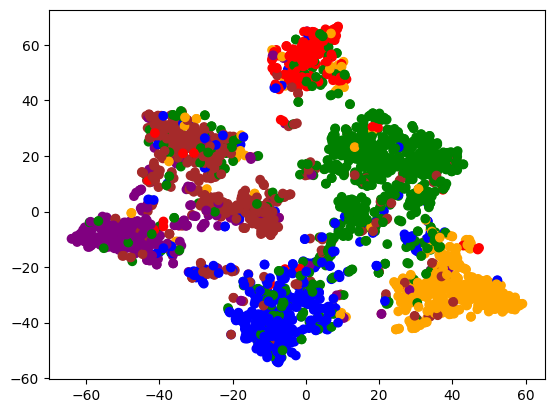

In [ ]:
color_list = ["red", "orange", "green", "blue", "purple", "brown"]

loader = DataLoader(dataset, batch_size=64, shuffle=True)
embs = []
colors = []
for batch in loader:
    emb, pred = model(batch)
    embs.append(emb)
    colors += [color_list[y-1] for y in batch.y]
embs = torch.cat(embs, dim=0)

xs, ys = zip(*TSNE().fit_transform(embs.detach().numpy()))
plt.scatter(xs, ys, color=colors)

In [ ]:
print("Length of color_list:", len(color_list))
print("Max value in batch.y:", max(batch.y))

Length of color_list: 6
Max value in batch.y: tensor(6)


# Learning unsupervised embeddings with graph autoencoders

Finally, GNNs fit nicely in the framework of other neural approaches, and can be used as part of autoencoder techniques, pretraining and multitask learning methods, etc. Here we explore the idea of neural network representations further by building a graph autoencoder which learns these representations in a completely unsupervised way. In contrast to the previous example, we do not make use of the given node labels when training this representation. Instead, we encode the nodes in our network in a low-dimensional space in such a way that the embeddings can be decoded into a reconstruction of the original network. We use graph convolutional layers in the encoder.

You can again use TensorBoardX here to visualize the training progress.

In [ ]:
from torch_geometric.utils import train_test_split_edges


In [ ]:
import torch
import torch.nn.functional as F
import torch_geometric.nn as pyg_nn
from torch_geometric.datasets import Planetoid
import torch_geometric.transforms as T
from torch_geometric.utils import train_test_split_edges
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

class Encoder(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super(Encoder, self).__init__()
        self.conv1 = pyg_nn.GCNConv(in_channels, 2 * out_channels, cached=True)
        self.conv2 = pyg_nn.GCNConv(2 * out_channels, out_channels, cached=True)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

def train(epoch):
    model.train()
    optimizer.zero_grad()
    z = model.encode(x, train_pos_edge_index)
    loss = model.recon_loss(z, train_pos_edge_index)
    loss.backward()
    optimizer.step()

    writer.add_scalar("loss", loss.item(), epoch)

def test(pos_edge_index, neg_edge_index):
    model.eval()
    with torch.no_grad():
        z = model.encode(x, train_pos_edge_index)
    return model.test(z, pos_edge_index, neg_edge_index)

writer = SummaryWriter("./log/" + datetime.now().strftime("%Y%m%d-%H%M%S"))
transform = T.NormalizeFeatures()
dataset = Planetoid("/tmp/citeseer", "Citeseer", transform=transform)
data = dataset[0]

channels = 16
dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('CUDA availability:', torch.cuda.is_available())

# encoder: written by us; decoder: default (inner product)
model = pyg_nn.GAE(Encoder(dataset.num_features, channels)).to(dev)
labels = data.y
data.train_mask = data.val_mask = data.test_mask = data.y = None

# Split the edges using 'train_test_split_edges'
data = train_test_split_edges(data)

x, train_pos_edge_index = data.x.to(dev), data.train_pos_edge_index.to(dev)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(1, 201):
    train(epoch)
    auc, ap = test(data.test_pos_edge_index, data.test_neg_edge_index)
    writer.add_scalar("AUC", auc, epoch)
    writer.add_scalar("AP", ap, epoch)
    if epoch % 10 == 0:
        print('Epoch: {:03d}, AUC: {:.4f}, AP: {:.4f}'.format(epoch, auc, ap))


Processing...
Done!


CUDA availability: False


/usr/local/lib/python3.9/dist-packages/torch_geometric/deprecation.py:22: UserWarning: 'train_test_split_edges' is deprecated, use 'transforms.RandomLinkSplit' instead
  warnings.warn(out)


Epoch: 010, AUC: 0.6825, AP: 0.7362
Epoch: 020, AUC: 0.7479, AP: 0.7644
Epoch: 030, AUC: 0.7686, AP: 0.7866
Epoch: 040, AUC: 0.7865, AP: 0.8043
Epoch: 050, AUC: 0.8160, AP: 0.8280
Epoch: 060, AUC: 0.8523, AP: 0.8555
Epoch: 070, AUC: 0.8563, AP: 0.8622
Epoch: 080, AUC: 0.8656, AP: 0.8724
Epoch: 090, AUC: 0.8775, AP: 0.8835
Epoch: 100, AUC: 0.8775, AP: 0.8844
Epoch: 110, AUC: 0.8726, AP: 0.8796
Epoch: 120, AUC: 0.8741, AP: 0.8810
Epoch: 130, AUC: 0.8754, AP: 0.8827
Epoch: 140, AUC: 0.8798, AP: 0.8863
Epoch: 150, AUC: 0.8853, AP: 0.8901
Epoch: 160, AUC: 0.8893, AP: 0.8928
Epoch: 170, AUC: 0.8874, AP: 0.8899
Epoch: 180, AUC: 0.8870, AP: 0.8896
Epoch: 190, AUC: 0.8875, AP: 0.8895
Epoch: 200, AUC: 0.8884, AP: 0.8905


Finally, we plot our embeddings (the output of the encoder) with TSNE. We color each node embedding according to its label -- but note that we did not use any label information when training our encoder.

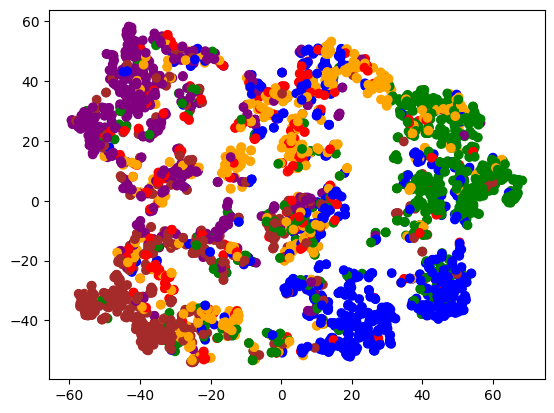

In [ ]:
model.eval()
z = model.encode(x, train_pos_edge_index)
colors = [color_list[y] for y in labels]

xs, ys = zip(*TSNE().fit_transform(z.cpu().detach().numpy()))
plt.scatter(xs, ys, color=colors)
plt.show()